# Lab 08 — Genetic Algorithms: Regression and Reproducibility

A real-valued genetic algorithm (GA) is verified on a one-dimensional objective, then used
to fit medical-cost regression coefficients over ten independent seeds and compared with
ordinary least squares, which solves this particular problem exactly.

**How to run.** Open this notebook from the `all_experiments` folder and choose *Run All*.
Evidence is written to `results/lab08/`.

**Questions**

1. Verify the evolutionary loop on $f(x) = (x-3)^2$.
2. Prepare the regression task.
3. Define the chromosome, fitness and operators.
4. Run ten independent seeds.
5. Compare with least squares.
6. Run one sensitivity study (population 100 → 40).

## Setup

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent
DATA = ROOT / "all_datasets"
RESULTS = ROOT / "results" / "lab08"
RESULTS.mkdir(parents=True, exist_ok=True)

## Question 1 — Verify the evolutionary loop

Before touching real data, minimise $f(x) = (x-3)^2$ with a small real-valued GA —
tournament selection, blend crossover, Gaussian mutation, two elites — and confirm that the
best solution approaches $x = 3$.

In [2]:
def ga_scalar(seed=42, pop_size=40, generations=80, n_elite=2):
    rng = np.random.default_rng(seed)
    population = rng.uniform(-10, 10, pop_size)
    for _ in range(generations):
        fitness = (population - 3) ** 2                                  # lower is better
        elite = population[np.argsort(fitness)[:n_elite]]
        # Tournament selection: the best of three random individuals becomes a parent.
        contestants = rng.integers(0, pop_size, size=(pop_size, 3))
        parents = population[contestants[np.arange(pop_size), fitness[contestants].argmin(axis=1)]]
        # Blend crossover between consecutive parents, then Gaussian mutation.
        a, b = parents[0::2], parents[1::2]
        alpha = rng.random(len(a))
        children = np.r_[alpha * a + (1 - alpha) * b, alpha * b + (1 - alpha) * a][: pop_size - n_elite]
        children += rng.normal(0, 0.15, len(children))
        population = np.r_[elite, children]                              # elites survive unchanged
    best = population[np.argmin((population - 3) ** 2)]
    return best, (best - 3) ** 2


x_best, f_best = ga_scalar()
print(f"Best x = {x_best:.6f}   f(x) = {f_best:.8f}")

Best x = 2.999989   f(x) = 0.00000000


**Answer.** The best individual lands within about $10^{-4}$ of $x = 3$ after 80
generations. The loop — evaluate, keep elites, select by tournament, blend, mutate, replace
— is the same loop the regression GA uses below, so a bug would show up here first.

## Question 2 — Prepare the regression task

Predict `charges` from age, BMI, number of children and smoker status (0/1). Split 80/20
with seed 42, standardise the predictors with training statistics only, and save the split.

In [3]:
insurance = pd.read_csv(DATA / "lab08-insurance.csv")
X = insurance[["age", "bmi", "children"]].assign(smoker=(insurance.smoker == "yes").astype(float))
y = insurance.charges.to_numpy()

train, test = train_test_split(insurance.index, test_size=0.20, random_state=42)
pd.Series(np.where(insurance.index.isin(test), "test", "train"), name="split").rename_axis("row_id").to_csv(RESULTS / "split.csv")

scaler = StandardScaler().fit(X.loc[train])
X_train, X_test = scaler.transform(X.loc[train]), scaler.transform(X.loc[test])
y_train, y_test = y[train], y[test]
print({"rows": len(insurance), "train": len(train), "test": len(test), "predictors": list(X.columns)})

{'rows': 1338, 'train': 1070, 'test': 268, 'predictors': ['age', 'bmi', 'children', 'smoker']}


**Answer.** 1,070 training and 268 test rows. Standardising the inputs puts all four
coefficients on a comparable scale, which matters for a GA because one mutation step size is
used for every coefficient gene.

## Question 3 — Define the chromosome, fitness and operators

A chromosome has five real-valued genes: the intercept and four coefficients. Fitness is
the training mean squared error. Write `run_ga` with tournament selection, blend crossover,
Gaussian mutation and elitism, returning train RMSE, test RMSE, runtime and the best-so-far
history. Run it once to check that it works.

In [4]:
def run_ga(seed, pop_size=100, generations=160, mutation_rate=0.15, mutation_scale=0.25, n_elite=4):
    rng = np.random.default_rng(seed)
    n_genes = X_train.shape[1] + 1
    population = rng.normal(0, 5000, size=(pop_size, n_genes))
    population[:, 0] += y_train.mean()                                   # intercepts start near the mean charge
    gene_scale = np.r_[2000, np.repeat(1000, n_genes - 1)]               # mutation size per gene

    def training_mse(individuals):
        predictions = individuals[:, [0]] + individuals[:, 1:] @ X_train.T
        return ((predictions - y_train) ** 2).mean(axis=1)

    best, best_mse, history = None, np.inf, []
    started = time.perf_counter()
    for _ in range(generations):
        fitness = training_mse(population)
        if fitness.min() < best_mse:
            best_mse, best = fitness.min(), population[fitness.argmin()].copy()
        history.append(best_mse)

        elite = population[np.argsort(fitness)[:n_elite]]
        contestants = rng.integers(0, pop_size, size=(pop_size, 3))
        parents = population[contestants[np.arange(pop_size), fitness[contestants].argmin(axis=1)]]
        a, b = parents[0::2], parents[1::2]
        alpha = rng.uniform(-0.1, 1.1, size=(len(a), 1))
        children = np.vstack([alpha * a + (1 - alpha) * b, alpha * b + (1 - alpha) * a])[: pop_size - n_elite]
        mutate = rng.random(children.shape) < mutation_rate
        children += mutate * rng.normal(0, mutation_scale, size=children.shape) * gene_scale
        population = np.vstack([elite, children])

    test_rmse = mean_squared_error(y_test, best[0] + X_test @ best[1:]) ** 0.5
    return {"seed": seed, "train_rmse": best_mse ** 0.5, "test_rmse": test_rmse,
            "runtime_s": time.perf_counter() - started, "coefficients": best, "history": np.sqrt(history)}


trial = run_ga(seed=1)
print(f"seed 1: train RMSE {trial['train_rmse']:.1f} | test RMSE {trial['test_rmse']:.1f} | {trial['runtime_s']:.2f} s")
print("Best chromosome [intercept, age, bmi, children, smoker]:", trial["coefficients"].round(1))

seed 1: train RMSE 6113.1 | test RMSE 5829.4 | 0.04 s
Best chromosome [intercept, age, bmi, children, smoker]: [13346.1  3616.3  1978.4   519.2  9559.3]


**Answer.** One run of 160 generations with a population of 100 takes a fraction of a
second and already produces a coefficient vector with a large positive smoker effect, as
expected. Each gene is a coefficient, so the GA searches the same space as least squares —
only without gradients.

## Question 4 — Run ten independent seeds

Repeat the GA for seeds 1–10, save train RMSE, test RMSE and runtime per seed to
`ga_10_runs.csv`, and summarise the spread across seeds.

In [5]:
def run_table(runs):
    return pd.DataFrame(runs)[["seed", "train_rmse", "test_rmse", "runtime_s"]]


runs = [run_ga(seed) for seed in range(1, 11)]
results = run_table(runs)
results.to_csv(RESULTS / "ga_10_runs.csv", index=False)
display(results.round(3))
print(f"Median test RMSE {results.test_rmse.median():.2f} | SD across seeds {results.test_rmse.std():.4f}")

,seed,train_rmse,test_rmse,runtime_s
0,1,6113.068,5829.378,0.054
1,2,6113.068,5829.379,0.039
2,3,6113.068,5829.378,0.037
3,4,6113.068,5829.377,0.038
4,5,6113.068,5829.381,0.037
5,6,6113.068,5829.375,0.041
6,7,6113.068,5829.377,0.039
7,8,6113.068,5829.380,0.037
8,9,6113.068,5829.380,0.039
9,10,6113.068,5829.380,0.037


Median test RMSE 5829.38 | SD across seeds 0.0019


**Answer.** All ten seeds converge to practically the same solution: the standard deviation
of test RMSE across seeds is a few thousandths on a scale of thousands. This is the
reproducibility evidence a single lucky run cannot provide.

## Question 5 — Compare with least squares

Fit ordinary least squares on the identical split and preprocessing, compare its test RMSE
and coefficients with the GA, and plot the best-so-far training RMSE of five seeds against
the OLS training RMSE.

OLS test RMSE: 5829.38
OLS coefficients:    [3616.3 1978.4  519.2 9559.3]
Median GA coefficients: [3616.3 1978.4  519.2 9559.3]


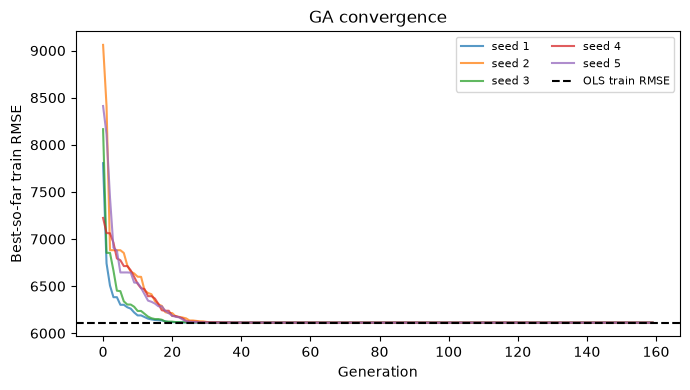

In [6]:
ols = LinearRegression().fit(X_train, y_train)
ols_test_rmse = mean_squared_error(y_test, ols.predict(X_test)) ** 0.5
ols_train_rmse = mean_squared_error(y_train, ols.predict(X_train)) ** 0.5
print("OLS test RMSE:", round(ols_test_rmse, 2))
print("OLS coefficients:   ", ols.coef_.round(1))
print("Median GA coefficients:", np.median([r["coefficients"][1:] for r in runs], axis=0).round(1))

fig, ax = plt.subplots(figsize=(7, 4))
for r in runs[:5]:
    ax.plot(r["history"], alpha=0.75, label=f"seed {r['seed']}")
ax.axhline(ols_train_rmse, linestyle="--", color="black", label="OLS train RMSE")
ax.set(xlabel="Generation", ylabel="Best-so-far train RMSE", title="GA convergence")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "convergence.png", dpi=160)

**Answer.** The GA's median test RMSE equals the OLS test RMSE to within rounding, and its
coefficients match the OLS coefficients. Every seed drops onto the OLS line within a few
dozen generations. The GA has *found* the optimum; it has not *beaten* it — for an
unconstrained least-squares problem the closed-form solution is exact and far cheaper.

## Question 6 — Run one sensitivity study

Reduce the population from 100 to 40, repeat the ten seeds, and compare median test RMSE,
its spread and runtime for both settings and OLS. Save `ga_sensitivity_pop40.csv` and
`summary.csv`.

In [7]:
small = run_table(run_ga(seed, pop_size=40) for seed in range(1, 11))
small.to_csv(RESULTS / "ga_sensitivity_pop40.csv", index=False)

summary = pd.DataFrame([
    {"method": "GA pop=100", "median_test_rmse": results.test_rmse.median(), "sd_test_rmse": results.test_rmse.std(), "median_runtime_s": results.runtime_s.median()},
    {"method": "GA pop=40", "median_test_rmse": small.test_rmse.median(), "sd_test_rmse": small.test_rmse.std(), "median_runtime_s": small.runtime_s.median()},
    {"method": "OLS", "median_test_rmse": ols_test_rmse, "sd_test_rmse": 0.0, "median_runtime_s": np.nan},
])
summary.to_csv(RESULTS / "summary.csv", index=False)
display(summary.round(4))
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

,method,median_test_rmse,sd_test_rmse,median_runtime_s
0,GA pop=100,5829.3787,0.0019,0.0381
1,GA pop=40,5829.3819,0.0255,0.0167
2,OLS,5829.3785,0.0000,NaN


Saved: ['convergence.png', 'ga_10_runs.csv', 'ga_sensitivity_pop40.csv', 'split.csv', 'summary.csv']


**Answer.** Cutting the population to 40 more than halves the runtime and leaves the
median RMSE essentially unchanged, but the spread across seeds grows: a smaller population
has less diversity and depends more on its starting point. A GA is justified when the
objective is non-differentiable, discrete or awkwardly constrained; here it mainly shows
that a stochastic optimiser must be judged over repeated seeds, never from one run.